# Imports

In [1]:
import pickle
from collections import Counter
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from beatmap_classifier.classifier.utils_training import (get_data, get_additional_features, pad_sequences_pt,
                                                          train_and_evaluate, plot_training_history, load_pytorch_models)
from beatmap_classifier.classifier.augment_faster import augment_dataset, extract_movement_features_from_X

# Model Testing

Go run test_model.py

# Initializing some Data

In [2]:
TOURNAMENT_MODS = {
    "nm1": "NM",
    "nm2": "NM",
    "nm3": "NM",
    "nm4": "NM",
    "nm5": "NM",
    "nm6": "NM",
    "hd1": "HD",
    "hd2": "HD",
    "hd3": "HD",
    "hr1": "HR",
    "hr2": "HR",
    "hr3": "HR",
    "dt1": "DT",
    "dt2_and_dt3": "DT",
    "dt4": "DT",
    "tiebreaker": "NM",
}

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

db_path = 'beatmaps.db'

X, y, beatmap_ids = get_data(db_path)
raw_additional_features, normalized_additional_features = get_additional_features(db_path, y, beatmap_ids)

Max Vector Length: 500.0
Max Time Diff: 86087.0
Tournament-labeled beatmaps: 3922
Max Vector Count: 6309
Original beatmaps: 3922


In [4]:
# Get the mod associated with each tournament label
mods_flattened = [
    TOURNAMENT_MODS[label]
    if TOURNAMENT_MODS[label]
    else "NM"
    for label in y
]

raw_additional_features_array = np.array([
    raw_additional_features[(beatmap_id, mod)]
    for beatmap_id, mod in zip(beatmap_ids, mods_flattened)
])

normalized_additional_features_array = np.array([
    normalized_additional_features[(beatmap_id, mod)]
    for beatmap_id, mod in zip(beatmap_ids, mods_flattened)
])

In [5]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    beatmap_ids_train,
    beatmap_ids_test,
) = train_test_split(
    X,
    y,
    beatmap_ids,
    test_size=0.2,
    random_state=42,
)

print(f"Final train size: {len(X_train)}")
print(f"Final test size:  {len(X_test)}")

Final train size: 3137
Final test size:  785


In [6]:
# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(y)

with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

y_train_numerical = label_encoder.transform(y_train)
y_test_numerical = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

y_train_numerical = torch.tensor(y_train_numerical, dtype=torch.long)
y_test_numerical = torch.tensor(y_test_numerical, dtype=torch.long)

# Pad sequences
sequence_lengths = np.array([len(seq) for seq in X])
max_length = int(np.percentile(sequence_lengths, 99))
max_length = 2 ** int(np.ceil(np.log2(max_length)))
max_length = min(max_length, 4096)

print(f"Using max sequence length: {max_length}")

X_train = pad_sequences_pt(
    X_train,
    maxlen=max_length,
    dtype=torch.float32
)

X_test = pad_sequences_pt(
    X_test,
    maxlen=max_length,
    dtype=torch.float32
)

print("Before metadata:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

Using max sequence length: 4096
Before metadata:
X_train: torch.Size([3137, 4096, 8])
X_test:  torch.Size([785, 4096, 8])


In [7]:
class_counts = Counter(y_train_numerical.numpy())

for cls, count in sorted(class_counts.items()):
    print(f"Class {cls}: {count}")

print(dict(enumerate(label_encoder.classes_)))

Class 0: 703
Class 1: 710
Class 2: 731
Class 3: 608
Class 4: 385
{0: np.str_('nm1'), 1: np.str_('nm2'), 2: np.str_('nm3'), 3: np.str_('nm4'), 4: np.str_('nm5')}


In [8]:
# Extract geometric summary vectors for each row in X_train and X_test
movement_features_train = np.array(
    [extract_movement_features_from_X(X_train[i]) for i in range(len(X_train))],
    dtype=np.float32,
)

movement_features_test = np.array(
    [extract_movement_features_from_X(X_test[i]) for i in range(len(X_test))],
    dtype=np.float32,
)

# NOTICE THAT WE SWITCH FROM NORMALIZED TO RAW ADDITIONAL FEATURES
# BECAUSE XGBOOST DOESN'T NEED SCALING

# Extract SQLite metadata features corresponding to train/test IDs
mods_flattened_train = [
    TOURNAMENT_MODS.get(label, "NM")
    for label in y_train
]

sql_features_train = np.array(
    [
        raw_additional_features[(b_id, mod)]
        for b_id, mod in zip(beatmap_ids_train, mods_flattened_train)
    ],
    dtype=np.float32,
)

mods_flattened_test = [
    TOURNAMENT_MODS.get(label, "NM")
    for label in y_test
]

sql_features_test = np.array(
    [
        raw_additional_features.get((b_id, mod))
        for b_id, mod in zip(beatmap_ids_test, mods_flattened_test)
    ],
    dtype=np.float32,
)

# Concatenate (SQL metadata + Movement geometric summary)
X_additional_train = np.hstack(
    [sql_features_train, movement_features_train]
)
X_additional_test = np.hstack(
    [sql_features_test, movement_features_test]
)

print(f"Full meta tabular train shape: {X_additional_train.shape}")
print(f"Full meta tabular test shape:  {X_additional_test.shape}")

Full meta tabular train shape: (3137, 24)
Full meta tabular test shape:  (785, 24)


# CNN Model (SKIP TO XGBOOST IF DESIRED)

--- Training Meta Fold 1/5 ---
Original samples: 2509 -> Augmented total: 10036
Epoch 1/50 - loss: 1.2561 - acc: 0.5305 - val_loss: 0.9490 - val_acc: 0.7134
Epoch 2/50 - loss: 1.0507 - acc: 0.6659 - val_loss: 0.8807 - val_acc: 0.7723
Epoch 3/50 - loss: 0.9742 - acc: 0.7273 - val_loss: 0.8010 - val_acc: 0.8041
Epoch 4/50 - loss: 0.9350 - acc: 0.7511 - val_loss: 0.7934 - val_acc: 0.8312
Epoch 5/50 - loss: 0.8731 - acc: 0.7900 - val_loss: 0.8929 - val_acc: 0.7357
Epoch 6/50 - loss: 0.8580 - acc: 0.7999 - val_loss: 0.7543 - val_acc: 0.8408
Epoch 7/50 - loss: 0.8227 - acc: 0.8168 - val_loss: 0.7953 - val_acc: 0.8010
Epoch 8/50 - loss: 0.8190 - acc: 0.8131 - val_loss: 0.9231 - val_acc: 0.7389
Epoch 9/50 - loss: 0.7897 - acc: 0.8376 - val_loss: 0.6790 - val_acc: 0.8646
Epoch 10/50 - loss: 0.7669 - acc: 0.8506 - val_loss: 0.6932 - val_acc: 0.8551
Epoch 11/50 - loss: 0.7639 - acc: 0.8538 - val_loss: 0.7108 - val_acc: 0.8599
Epoch 12/50 - loss: 0.7432 - acc: 0.8656 - val_loss: 0.9122 - val_acc: 

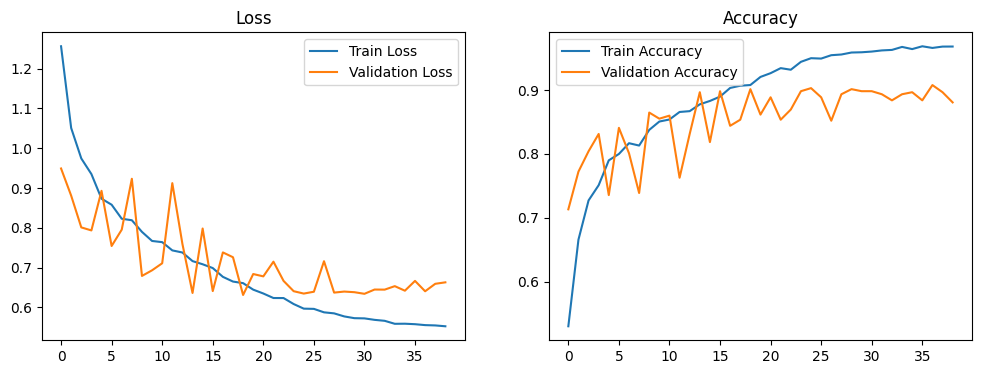

--- Training Meta Fold 2/5 ---
Original samples: 2509 -> Augmented total: 10036
Epoch 1/50 - loss: 1.2642 - acc: 0.5315 - val_loss: 0.9852 - val_acc: 0.7197
Epoch 2/50 - loss: 1.0467 - acc: 0.6664 - val_loss: 0.9178 - val_acc: 0.7596
Epoch 3/50 - loss: 0.9850 - acc: 0.7054 - val_loss: 0.9392 - val_acc: 0.7277
Epoch 4/50 - loss: 0.9423 - acc: 0.7400 - val_loss: 0.8090 - val_acc: 0.8041
Epoch 5/50 - loss: 0.9023 - acc: 0.7701 - val_loss: 0.9740 - val_acc: 0.7150
Epoch 6/50 - loss: 0.8871 - acc: 0.7804 - val_loss: 0.7876 - val_acc: 0.8217
Epoch 7/50 - loss: 0.8543 - acc: 0.7942 - val_loss: 0.7335 - val_acc: 0.8487
Epoch 8/50 - loss: 0.8411 - acc: 0.8018 - val_loss: 0.7397 - val_acc: 0.8583
Epoch 9/50 - loss: 0.8246 - acc: 0.8125 - val_loss: 0.7812 - val_acc: 0.8201
Epoch 10/50 - loss: 0.8119 - acc: 0.8222 - val_loss: 0.7965 - val_acc: 0.8121
Epoch 11/50 - loss: 0.7957 - acc: 0.8281 - val_loss: 0.6925 - val_acc: 0.8678
Epoch 12/50 - loss: 0.7685 - acc: 0.8435 - val_loss: 0.7305 - val_acc: 

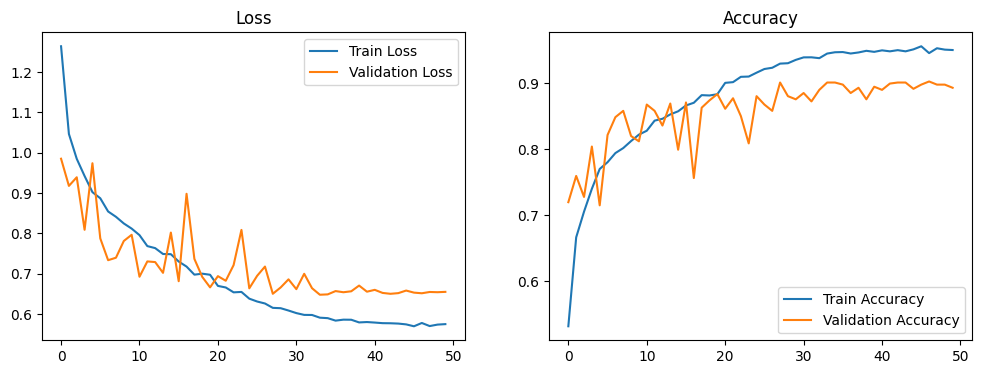

--- Training Meta Fold 3/5 ---
Original samples: 2510 -> Augmented total: 10040
Epoch 1/50 - loss: 1.3063 - acc: 0.5076 - val_loss: 1.0220 - val_acc: 0.7049
Epoch 2/50 - loss: 1.0694 - acc: 0.6602 - val_loss: 0.9554 - val_acc: 0.7241
Epoch 3/50 - loss: 0.9896 - acc: 0.7058 - val_loss: 0.8834 - val_acc: 0.7544
Epoch 4/50 - loss: 0.9404 - acc: 0.7457 - val_loss: 1.0236 - val_acc: 0.6794
Epoch 5/50 - loss: 0.9031 - acc: 0.7677 - val_loss: 0.8799 - val_acc: 0.7911
Epoch 6/50 - loss: 0.8799 - acc: 0.7849 - val_loss: 0.8094 - val_acc: 0.8102
Epoch 7/50 - loss: 0.8632 - acc: 0.7884 - val_loss: 0.8017 - val_acc: 0.8118
Epoch 8/50 - loss: 0.8319 - acc: 0.8106 - val_loss: 0.7713 - val_acc: 0.8262
Epoch 9/50 - loss: 0.8242 - acc: 0.8131 - val_loss: 0.7241 - val_acc: 0.8501
Epoch 10/50 - loss: 0.7981 - acc: 0.8292 - val_loss: 0.8955 - val_acc: 0.7608
Epoch 11/50 - loss: 0.7937 - acc: 0.8329 - val_loss: 0.9119 - val_acc: 0.7368
Epoch 12/50 - loss: 0.7763 - acc: 0.8437 - val_loss: 0.8257 - val_acc: 

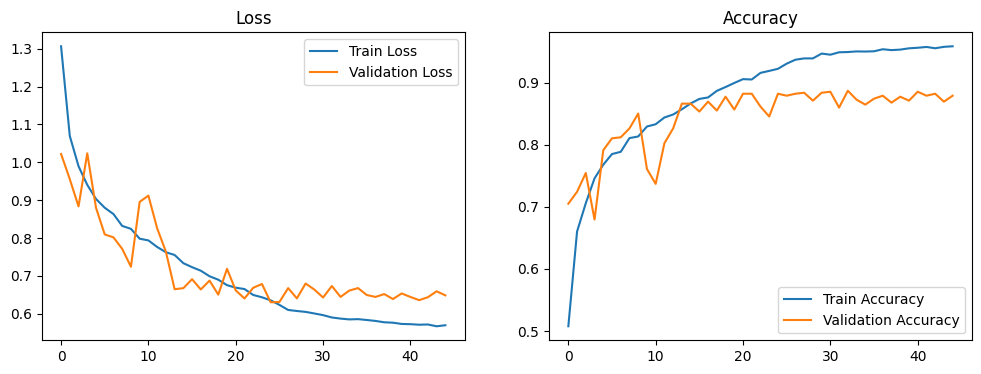

--- Training Meta Fold 4/5 ---
Original samples: 2510 -> Augmented total: 10040
Epoch 1/50 - loss: 1.2338 - acc: 0.5529 - val_loss: 0.9830 - val_acc: 0.7049
Epoch 2/50 - loss: 1.0216 - acc: 0.6948 - val_loss: 0.9031 - val_acc: 0.7384
Epoch 3/50 - loss: 0.9781 - acc: 0.7226 - val_loss: 0.8907 - val_acc: 0.7400
Epoch 4/50 - loss: 0.9420 - acc: 0.7490 - val_loss: 0.8733 - val_acc: 0.7671
Epoch 5/50 - loss: 0.9124 - acc: 0.7700 - val_loss: 0.8137 - val_acc: 0.7990
Epoch 6/50 - loss: 0.8816 - acc: 0.7833 - val_loss: 0.7958 - val_acc: 0.8070
Epoch 7/50 - loss: 0.8638 - acc: 0.7976 - val_loss: 0.7562 - val_acc: 0.8293
Epoch 8/50 - loss: 0.8341 - acc: 0.8115 - val_loss: 0.7327 - val_acc: 0.8453
Epoch 9/50 - loss: 0.8271 - acc: 0.8185 - val_loss: 0.7271 - val_acc: 0.8357
Epoch 10/50 - loss: 0.8126 - acc: 0.8210 - val_loss: 0.7882 - val_acc: 0.8230
Epoch 11/50 - loss: 0.7904 - acc: 0.8344 - val_loss: 0.7317 - val_acc: 0.8533
Epoch 12/50 - loss: 0.7782 - acc: 0.8416 - val_loss: 0.7023 - val_acc: 

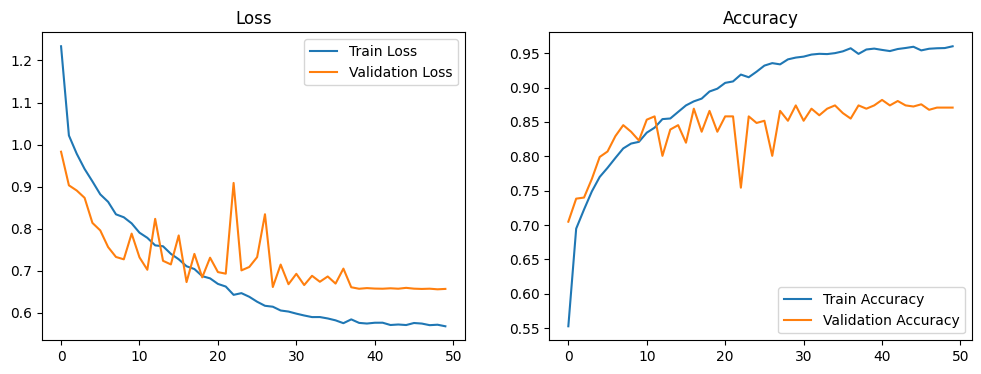

--- Training Meta Fold 5/5 ---
Original samples: 2510 -> Augmented total: 10040
Epoch 1/50 - loss: 1.1890 - acc: 0.5737 - val_loss: 0.9685 - val_acc: 0.7113
Epoch 2/50 - loss: 1.0175 - acc: 0.6920 - val_loss: 0.8997 - val_acc: 0.7703
Epoch 3/50 - loss: 0.9645 - acc: 0.7292 - val_loss: 0.8419 - val_acc: 0.8006
Epoch 4/50 - loss: 0.9311 - acc: 0.7472 - val_loss: 0.8221 - val_acc: 0.8134
Epoch 5/50 - loss: 0.8975 - acc: 0.7746 - val_loss: 0.7777 - val_acc: 0.8421
Epoch 6/50 - loss: 0.8661 - acc: 0.7975 - val_loss: 0.7386 - val_acc: 0.8437
Epoch 7/50 - loss: 0.8317 - acc: 0.8096 - val_loss: 0.7728 - val_acc: 0.8182
Epoch 8/50 - loss: 0.8124 - acc: 0.8273 - val_loss: 0.7201 - val_acc: 0.8612
Epoch 9/50 - loss: 0.7940 - acc: 0.8355 - val_loss: 0.8536 - val_acc: 0.7656
Epoch 10/50 - loss: 0.7796 - acc: 0.8451 - val_loss: 0.7417 - val_acc: 0.8357
Epoch 11/50 - loss: 0.7660 - acc: 0.8508 - val_loss: 1.1635 - val_acc: 0.6667
Epoch 12/50 - loss: 0.7502 - acc: 0.8609 - val_loss: 0.7313 - val_acc: 

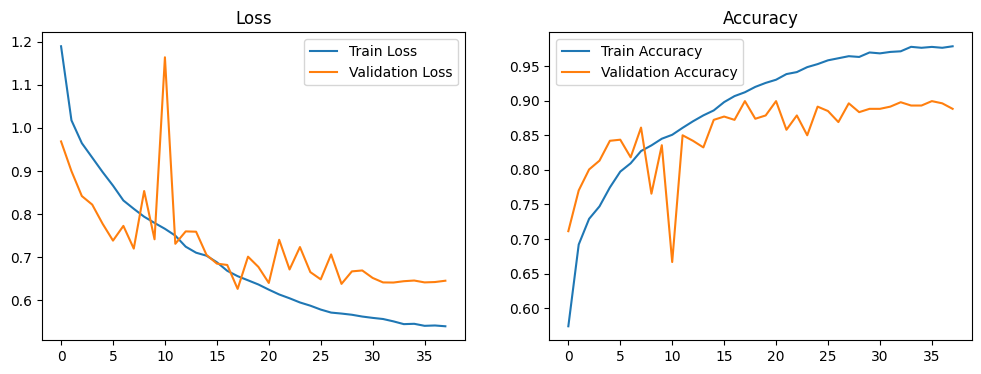

In [13]:
import numpy as np
import torch
from sklearn.model_selection import GroupKFold

meta_bagging_models = []
beatmap_ids_train = np.array(beatmap_ids_train)

# Initialize empty matrix for clean Out-Of-Fold CNN probability predictions
oof_cnn_predictions = np.zeros((len(X_train), num_classes), dtype=np.float32)

# Use GroupKFold so mapset difficulties stay grouped
gkf = GroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train_numerical, groups=beatmap_ids_train)):
    print(f"--- Training Meta Fold {fold + 1}/5 ---")

    # Split raw unaugmented fold data
    X_fold_train, y_fold_train = X_train[train_idx], y_train_numerical[train_idx]
    X_fold_val, y_fold_val = X_train[val_idx], y_train_numerical[val_idx]
    beatmap_ids_fold_train = beatmap_ids_train[train_idx]

    # Augment ONLY the training fold
    X_fold_train_aug, y_fold_train_aug, _ = augment_dataset(
        X_fold_train,
        y_fold_train,
        beatmap_ids_fold_train,
        augmentation_types={"horizontal", "vertical", "horizontal_vertical"}
    )

    # Convert validation fold to PyTorch Tensor (permuted to (B, C, L))
    X_fold_val = torch.as_tensor(X_fold_val, dtype=torch.float32).permute(0, 2, 1)
    y_fold_val = torch.as_tensor(y_fold_val, dtype=torch.long)

    X_fold_train_aug = X_fold_train_aug.permute(0, 2, 1)

    # Train CNN model for this fold
    model, history = train_and_evaluate(
        X_fold_train_aug,
        y_fold_train_aug,
        X_fold_val,
        y_fold_val,
        input_channels=X_fold_train_aug.shape[1],
        num_classes=num_classes,
        max_length=max_length,
        learning_rate=0.001,
        dropout_rate=0.5, # old: 0.5
        l2_reg=0.001,
        batch_size=128,
        epochs=50, # old: 30
        patience=20
    )
    plot_training_history(history)
    meta_bagging_models.append(model)

    # Generate Out-of-Fold predictions for the unaugmented validation set ONLY
    model.eval()
    with torch.no_grad():
        val_inputs = X_fold_val.to(device)
        logits = model(val_inputs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()

    # Store clean OOF predictions in the array
    oof_cnn_predictions[val_idx] = probs

In [14]:
import os

os.makedirs('models/bagged_models', exist_ok=True)

for i, model in enumerate(meta_bagging_models):
    torch.save(model.state_dict(), f'models/bagged_models/bagged_cnn_model_{i}.pth')

np.save("models/oof_cnn_predictions.npy", oof_cnn_predictions)
np.save("models/y_train_numerical.npy", y_train_numerical)
np.save("models/beatmap_ids_train.npy", np.array(beatmap_ids_train))

# XGBoost Meta Model

### Load Models and Data

In [15]:
from beatmap_classifier.classifier.cnn_model import CNNModel

model_kwargs = {
    "input_channels": 8,
    "num_classes": num_classes,
    "max_length": max_length,
    "dropout_rate": 0.5,
}

meta_bagging_models = load_pytorch_models(
    model_folder="models/bagged_models",
    model_class=CNNModel,
    model_kwargs=model_kwargs,
    device=device,
)

oof_cnn_predictions = np.load("models/oof_cnn_predictions.npy")
y_train_numerical = np.load("models/y_train_numerical.npy")

print(f"Loaded {len(meta_bagging_models)} CNN models")

Loaded 5 CNN models


### Test the bagging models

In [16]:
# Generate Test probabilities by averaging predictions across all fold models
X_test_tensor = torch.as_tensor(X_test, dtype=torch.float32).permute(0, 2, 1).to(device)
test_probs_list = []

for model in meta_bagging_models:
    model.eval()
    with torch.no_grad():
        logits = model(X_test_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        test_probs_list.append(probs)

bagged_test_predictions = np.mean(test_probs_list, axis=0)
bagged_test_predictions_numerical = np.argmax(bagged_test_predictions, axis=1)

score = accuracy_score(y_test_numerical, bagged_test_predictions_numerical)
cm = confusion_matrix(y_test_numerical, bagged_test_predictions_numerical)
report = classification_report(
    y_test_numerical,
    bagged_test_predictions_numerical,
    zero_division=0,
    target_names=["NM1", "NM2", "NM3", "NM4", "NM5"] # "DT1", "DT2_and_DT3", "HD2", "HR1", "HR2",
)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {score}")

Classification Report:
               precision    recall  f1-score   support

         NM1       0.96      0.97      0.97       192
         NM2       0.89      0.93      0.91       158
         NM3       0.90      0.91      0.90       186
         NM4       0.88      0.86      0.87       153
         NM5       0.84      0.78      0.81        96

    accuracy                           0.90       785
   macro avg       0.89      0.89      0.89       785
weighted avg       0.90      0.90      0.90       785

Confusion Matrix:
 [[186   1   2   2   1]
 [  0 147   2   0   9]
 [  3   1 169  11   2]
 [  2   4  14 131   2]
 [  2  13   1   5  75]]
Accuracy: 0.9019108280254777


### Setup

In [17]:
sql_feature_names = [
    "ar",
    "od",
    "circle_size",
    "star_rating",
    "bpm",
    "max_combo",
    "length_seconds",
    "object_count",
    "pp",
    "pp_aim",
    "pp_speed",
    "pp_acc"
]

movement_feature_names = [
    "slider_ratio",
    "slider_length_std",
    "speed_std",
    "speed_change_std",
    "speed_change_max",
    "angle_std",
    "angle_mean",
    "rhythm_variance",
    "distance_mean",
    "speed_change_95th",
    "angle_90th",
    "sharp_turn_ratio",
]

# {0: np.str_('dt1'), 1: np.str_('dt2_and_dt3'), 2: np.str_('hd2'), 3: np.str_('hr1'), 4: np.str_('hr2'), 5: np.str_('nm1'), 6: np.str_('nm2'), 7: np.str_('nm3'), 8: np.str_('nm4'), 9: np.str_('nm5')}

cnn_feature_names = [
    # "CNN_DT1",
    # "CNN_DT2_AND_DT3",
    # "CNN_HD2",
    # "CNN_HR1",
    # "CNN_HR2",
    "CNN_NM1",
    "CNN_NM2",
    "CNN_NM3",
    "CNN_NM4",
    "CNN_NM5",
]

additional_feature_names = (
    sql_feature_names +
    movement_feature_names
)

In [18]:
configs = [
    dict(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=4,
        min_child_weight=1,
        subsample=0.85,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=1.0,
    ),
]

In [19]:
print(additional_feature_names)

['ar', 'od', 'circle_size', 'star_rating', 'bpm', 'max_combo', 'length_seconds', 'object_count', 'pp', 'pp_aim', 'pp_speed', 'pp_acc', 'slider_ratio', 'slider_length_std', 'speed_std', 'speed_change_std', 'speed_change_max', 'angle_std', 'angle_mean', 'rhythm_variance', 'distance_mean', 'speed_change_95th', 'angle_90th', 'sharp_turn_ratio']


In [20]:
selected_features = [
    feature
    for feature in additional_feature_names
    # if feature != "slider_ratio"
]

additional_feature_groups = {
    "best": selected_features,
}

In [21]:
print(selected_features)

['ar', 'od', 'circle_size', 'star_rating', 'bpm', 'max_combo', 'length_seconds', 'object_count', 'pp', 'pp_aim', 'pp_speed', 'pp_acc', 'slider_ratio', 'slider_length_std', 'speed_std', 'speed_change_std', 'speed_change_max', 'angle_std', 'angle_mean', 'rhythm_variance', 'distance_mean', 'speed_change_95th', 'angle_90th', 'sharp_turn_ratio']


In [22]:
from sklearn.metrics import f1_score

def get_feature_indices(feature_names, selected_features):
    missing = [
        name for name in selected_features
        if name not in feature_names
    ]

    if missing:
        raise ValueError(f"Features not found: {missing}")

    return [feature_names.index(name) for name in selected_features]

def make_xgb(params):
    return XGBClassifier(
        random_state=42,
        objective="multi:softprob",
        num_class=5,
        eval_metric="mlogloss",
        **params
    )

def evaluate_feature_set(
    selected_features,
    X_additional_train,
    X_additional_test,
    oof_cnn_predictions,
    bagged_test_predictions,
    y_train,
    y_test,
    params,
    compare_feature_groups,
    indices
):

    if not compare_feature_groups:
        indices = [
            additional_feature_names.index(name)
            for name in selected_features
        ]

    X_meta_train = np.hstack([
        oof_cnn_predictions,
        X_additional_train[:, indices],
    ])

    X_meta_test = np.hstack([
        bagged_test_predictions,
        X_additional_test[:, indices],
    ])

    model = make_xgb(params)
    model.fit(X_meta_train, y_train)

    pred = model.predict(X_meta_test)

    acc = accuracy_score(y_test, pred)
    macro_f1 = f1_score(y_test, pred, average="macro")
    cm = confusion_matrix(y_test, pred)

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "nm3_to_nm4": cm[2, 3],
        "nm4_to_nm3": cm[3, 2],
    }, model, pred

### Compare the XGBoost Classifiers within Feature Groups

In [23]:
from xgboost import XGBClassifier

feature_indices = {
    group_name: [
        additional_feature_names.index(feature)
        for feature in features
    ]
    for group_name, features in additional_feature_groups.items()
}

for group_name, indices in feature_indices.items():
    print("=" * 80)
    print(f"FEATURE GROUP: {group_name}")
    print("=" * 80)

    for i, params in enumerate(configs):

        results, model, pred = evaluate_feature_set(
            selected_features=None,
            X_additional_train=X_additional_train,
            X_additional_test=X_additional_test,
            oof_cnn_predictions=oof_cnn_predictions,
            bagged_test_predictions=bagged_test_predictions,
            y_train=y_train_numerical,
            y_test=y_test_numerical,
            params=configs[0],
            compare_feature_groups=True,
            indices=indices
        )

        report = classification_report(y_test_numerical, pred, output_dict=True, zero_division=0)
        print(f"Config {i}: accuracy={results["accuracy"] * 100:.2f}% | macro_f1={results["macro_f1"]:.4f}")

FEATURE GROUP: best
Config 0: accuracy=93.12% | macro_f1=0.9274


### Compare the XGBoost Classifiers by removing single features

In [24]:
import pandas as pd

all_features = additional_feature_groups["best"]

baseline, meta_model, y_pred_meta = evaluate_feature_set(
    selected_features=all_features,
    X_additional_train=X_additional_train,
    X_additional_test=X_additional_test,
    oof_cnn_predictions=oof_cnn_predictions,
    bagged_test_predictions=bagged_test_predictions,
    y_train=y_train_numerical,
    y_test=y_test_numerical,
    params=configs[0],
    compare_feature_groups=False,
    indices=None
)

with open("models/meta_model.pkl", "wb") as f:
    pickle.dump(meta_model, f)

print("Baseline:")
print(baseline)

baseline_acc = baseline["accuracy"]
baseline_f1 = baseline["macro_f1"]

array_results = []

for removed_feature in all_features:

    remaining_features = [
        feature
        for feature in all_features
        if feature != removed_feature
    ]

    results, _, _ = evaluate_feature_set(
        selected_features=remaining_features,
        X_additional_train=X_additional_train,
        X_additional_test=X_additional_test,
        oof_cnn_predictions=oof_cnn_predictions,
        bagged_test_predictions=bagged_test_predictions,
        y_train=y_train_numerical,
        y_test=y_test_numerical,
        params=configs[0],
        compare_feature_groups=False,
        indices=None
    )

    dict_results = {
        "removed": removed_feature,
        "accuracy": results["accuracy"],
        "macro_f1": results["macro_f1"],
        "acc_delta": results["accuracy"] - baseline_acc,
        "f1_delta": results["macro_f1"] - baseline_f1,
        "nm3_to_nm4": results["nm3_to_nm4"],
        "nm4_to_nm3": results["nm4_to_nm3"]
    }

    array_results.append(dict_results)

results_df = pd.DataFrame(array_results)

results_df = results_df.sort_values(
    "acc_delta",
    ascending=False
)

print(results_df.to_string(index=False))

Baseline:
{'accuracy': 0.9312101910828026, 'macro_f1': 0.9274288588924774, 'nm3_to_nm4': np.int64(10), 'nm4_to_nm3': np.int64(7)}
          removed  accuracy  macro_f1  acc_delta  f1_delta  nm3_to_nm4  nm4_to_nm3
 sharp_turn_ratio  0.935032  0.933131   0.003822  0.005702          10           7
   length_seconds  0.932484  0.929706   0.001274  0.002277          10           7
       angle_mean  0.932484  0.929730   0.001274  0.002301          10           7
speed_change_95th  0.932484  0.929533   0.001274  0.002104          10           8
        speed_std  0.931210  0.926692   0.000000 -0.000737          11           7
      star_rating  0.931210  0.927384   0.000000 -0.000045          10           7
     slider_ratio  0.931210  0.927988   0.000000  0.000560          10           8
  rhythm_variance  0.931210  0.928474   0.000000  0.001045          11           7
    distance_mean  0.929936  0.926767  -0.001274 -0.000662          11           8
       angle_90th  0.929936  0.926688  -

### Testing our best (aka baseline) XGBoost Model

In [26]:
indices = [
    additional_feature_names.index(name)
    for name in selected_features
]

X_meta_train = np.hstack([
    oof_cnn_predictions,
    X_additional_train[:, indices],
])

X_meta_test = np.hstack([
    bagged_test_predictions,
    X_additional_test[:, indices],
])

test_acc = accuracy_score(y_test_numerical, y_pred_meta)

print(f"--- XGBoost Meta-Model Performance ---")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test_numerical, y_pred_meta, target_names=["NM1", "NM2", "NM3", "NM4", "NM5"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test_numerical, y_pred_meta))

--- XGBoost Meta-Model Performance ---
Final Test Accuracy: 93.12%

Classification Report:
              precision    recall  f1-score   support

         NM1       0.96      0.98      0.97       192
         NM2       0.91      0.95      0.93       158
         NM3       0.94      0.90      0.92       186
         NM4       0.90      0.92      0.91       153
         NM5       0.93      0.88      0.90        96

    accuracy                           0.93       785
   macro avg       0.93      0.93      0.93       785
weighted avg       0.93      0.93      0.93       785

Confusion Matrix:
[[188   0   1   3   0]
 [  0 150   2   1   5]
 [  5   2 168  10   1]
 [  2   3   7 141   0]
 [  1   9   1   1  84]]


# Analysis

In [27]:
importance = meta_model.feature_importances_
meta_model_features = cnn_feature_names + selected_features

for name, value in sorted(
    zip(meta_model_features, importance),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{name:30s} {value:.4f}")

CNN_NM1                        0.1733
CNN_NM2                        0.1673
CNN_NM3                        0.1477
CNN_NM4                        0.1354
CNN_NM5                        0.1136
bpm                            0.0356
sharp_turn_ratio               0.0304
distance_mean                  0.0226
slider_ratio                   0.0215
slider_length_std              0.0173
angle_mean                     0.0142
pp_speed                       0.0121
od                             0.0093
speed_std                      0.0090
pp_acc                         0.0089
length_seconds                 0.0084
angle_90th                     0.0081
star_rating                    0.0080
pp_aim                         0.0078
ar                             0.0076
angle_std                      0.0075
rhythm_variance                0.0075
object_count                   0.0072
max_combo                      0.0069
pp                             0.0068
circle_size                    0.0061
speed_change

In [28]:
feature_names = [
    "AR",
    "OD",
    "Circle Size",
    "Star Rating",
    "BPM",
    "Max Combo",
    "Length (s)",
    "Object Count",
]

print("\nRaw Additional feature ranges:")
print("-" * 70)

for i, name in enumerate(feature_names):
    values = raw_additional_features_array[:, i]

    print(
        f"{name:15s} "
        f"min={np.min(values):8.2f}  "
        f"max={np.max(values):8.2f}  "
        f"mean={np.mean(values):8.2f}  "
        f"median={np.median(values):8.2f}"
    )

print("\nRaw Additional feature percentiles:")
print("-" * 90)

for i, name in enumerate(feature_names):
    values = raw_additional_features_array[:, i]

    p = np.percentile(values, [1, 5, 25, 50, 75, 95, 99])

    print(
        f"{name:15s} "
        f"1%={p[0]:8.2f}  "
        f"5%={p[1]:8.2f}  "
        f"25%={p[2]:8.2f}  "
        f"50%={p[3]:8.2f}  "
        f"75%={p[4]:8.2f}  "
        f"95%={p[5]:8.2f}  "
        f"99%={p[6]:8.2f}"
    )


Raw Additional feature ranges:
----------------------------------------------------------------------
AR              min=    6.80  max=   10.00  mean=    9.50  median=    9.50
OD              min=    5.00  max=   10.00  mean=    8.86  median=    9.00
Circle Size     min=    2.00  max=    7.00  mean=    4.01  median=    4.00
Star Rating     min=    3.12  max=   19.09  mean=    6.79  median=    6.73
BPM             min=   50.00  max=  363.86  mean=  184.70  median=  185.00
Max Combo       min=  252.00  max=10215.00  mean= 1526.90  median= 1449.50
Length (s)      min=   18.29  max= 1645.53  mean=  192.91  median=  194.45
Object Count    min=  156.00  max= 6310.00  mean= 1086.00  median= 1022.00

Raw Additional feature percentiles:
------------------------------------------------------------------------------------------
AR              1%=    9.00  5%=    9.20  25%=    9.40  50%=    9.50  75%=    9.60  95%=    9.80  99%=   10.00
OD              1%=    7.50  5%=    8.00  25%=    8.50  50

In [29]:
bpm = raw_additional_features_array[:, 4]
for threshold in [300, 400, 500, 600, 800, 1000]:
    count = np.sum(bpm > threshold)

    print(
        f"bpm > {threshold:4d}: "
        f"{count:6d} "
        f"({count / len(bpm) * 100:.3f}%)"
    )

bpm >  300:     10 (0.255%)
bpm >  400:      0 (0.000%)
bpm >  500:      0 (0.000%)
bpm >  600:      0 (0.000%)
bpm >  800:      0 (0.000%)
bpm > 1000:      0 (0.000%)


In [30]:
sequence_lengths = np.array([len(seq) for seq in X])

print("Number of beatmaps:", len(sequence_lengths))
print("Min:", sequence_lengths.min())
print("Median:", np.median(sequence_lengths))
print("Mean:", sequence_lengths.mean())
print("75th:", np.percentile(sequence_lengths, 75))
print("90th:", np.percentile(sequence_lengths, 90))
print("95th:", np.percentile(sequence_lengths, 95))
print("99th:", np.percentile(sequence_lengths, 99))
print("Max:", sequence_lengths.max())

Number of beatmaps: 3922
Min: 155
Median: 1021.0
Mean: 1085.0012748597653
75th: 1246.0
90th: 1577.9
95th: 1874.0
99th: 2545.0599999999995
Max: 6309
